### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [3]:
# 1. Завантаження даних
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

In [4]:
X.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Income_not_filled,days_lifetime,years_customer,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,marital_Else,marital_Single
0,1957,58138,0,0,58,635,88,546,172,88,...,False,663,57,0,0,1,0,0,0,0
1,1954,46344,1,1,38,11,1,6,2,1,...,False,113,60,0,0,1,0,0,0,0
2,1965,71613,0,0,26,426,49,127,111,21,...,False,312,49,0,0,1,0,0,0,0
3,1984,26646,1,0,26,11,4,20,10,3,...,False,139,30,0,0,1,0,0,0,0
4,1981,58293,1,0,94,173,43,118,46,27,...,False,161,33,0,0,0,0,1,0,0


In [5]:
print(f"Розмір датасету: {X.shape[0]} рядків, {X.shape[1]} колонок")
print(f"Пропущені значення: {X.isna().sum().sum()}")

Розмір датасету: 2239 рядків, 35 колонок
Пропущені значення: 0


### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [6]:
# 1. Відбираємо ключові характеристики
features = ['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases',
            'days_lifetime', 'years_customer', 'NumWebVisitsMonth']
X_selected = X[features]

X_selected.describe().round(2)

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
count,2239.00,2239.00,2239.00,2239.00,2239.00,2239.00,2239.00
mean,51412.78,49.12,5.79,2.32,353.56,45.20,5.32
std,22069.61,28.96,3.25,1.93,202.17,11.99,2.43
min,-1.00,0.00,0.00,0.00,0.00,18.00,0.00
25%,34716.00,24.00,3.00,1.00,180.50,37.00,3.00
50%,51039.00,49.00,5.00,2.00,355.00,44.00,6.00
75%,68277.50,74.00,8.00,3.00,529.00,55.00,7.00
max,162397.00,99.00,13.00,15.00,699.00,121.00,20.00


In [7]:
# 2. Стандартизація
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [8]:
# 3. Кластеризація KMeans з 3 кластерами
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print("Розподіл по кластерах:")
print(pd.Series(clusters).value_counts().sort_index())

Розподіл по кластерах:
0    961
1    823
2    455
Name: count, dtype: int64


In [9]:
# 4. PCA до 3 компонент
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [10]:
# 5. Візуалізація результатів

# 3D-графік
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = clusters.astype(str)

fig = px.scatter_3d(
    df_pca,
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title='3D PCA: кластеризація клієнтів (KMeans, K=3)',
    opacity=0.7
)
fig.show()

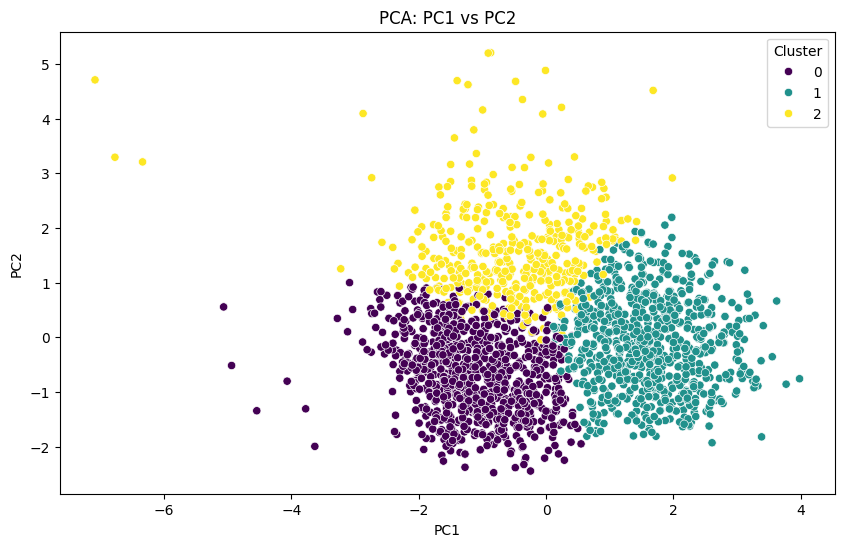

In [11]:
# Додатково: 2D scatter (для наочності)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.legend(title='Cluster')
plt.show()

In [12]:
sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette score: {sil_score:.4f}")

Silhouette score: 0.2150


У просторі головних компонент (2D та 3D) кластери візуально формують окремі групи, однак між ними спостерігається перекриття, особливо на межах. Значення silhouette score становить 0.215, що свідчить про слабку якість кластеризації: точки не завжди чітко відносяться до своїх кластерів і часто знаходяться близько до інших кластерів. Це означає, що обрані ознаки та/або кількість кластерів не дозволяють сформувати добре відокремлені сегменти клієнтів, і структура даних є досить складною.

Метод PCA при цьому ефективно зменшив розмірність даних і дозволив наочно побачити загальну структуру. Отже, хоча KMeans виділив певні групи клієнтів, отримана сегментація є обмежено інформативною і може потребувати додаткового підбору ознак або параметрів моделі.

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [13]:
# Частка поясненої дисперсії
print("Частка поясненої дисперсії:\n")
for i, ratio in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

Частка поясненої дисперсії:

PC1: 0.3185 (31.85%)
PC2: 0.1966 (19.66%)
PC3: 0.1434 (14.34%)


In [14]:
# Кумулятивна
var_exp = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)

print(f"Кумулятивна частка:\n")
for i, cum in enumerate(cum_var_exp, 1):
    print(f"PC1-PC{i}: {cum:.4f} ({cum*100:.2f}%)")

Кумулятивна частка:

PC1-PC1: 0.3185 (31.85%)
PC1-PC2: 0.5151 (51.51%)
PC1-PC3: 0.6585 (65.85%)


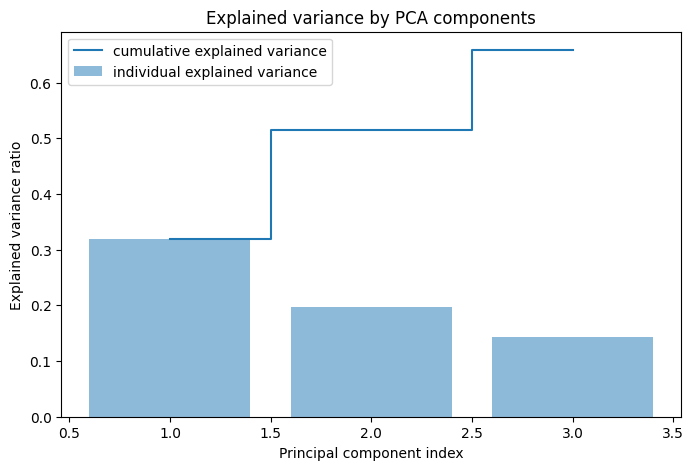

In [15]:
plt.figure(figsize=(8,5))

plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.5, label='individual explained variance')
plt.step(range(1, len(cum_var_exp)+1), cum_var_exp, where='mid', label='cumulative explained variance')

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Explained variance by PCA components')
plt.legend(loc='best')
plt.show()

Перша головна компонента (PC1) пояснює 31.85% загальної варіації даних, друга — 19.66%, а третя — 14.34%. Кумулятивно перші три компоненти пояснюють близько 65.85% загальної дисперсії, що означає, що більша частина інформації збережена, однак приблизно третина варіації все ще втрачається.

Також на візуалізації бачимо, що найбільший вклад у варіацію робить перша компонента, після чого внесок кожної наступної компоненти зменшується.

Отже, використання трьох головних компонент є достатнім для базової візуалізації та аналізу структури даних, однак для більш точного відтворення інформації може знадобитися більша кількість компонент.

### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [16]:
# DataFrame з loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features
)
loadings.round(4)

,PC1,PC2,PC3
Income,0.5842,0.1653,-0.0445
Recency,0.0101,0.0368,0.9758
NumStorePurchases,0.4886,0.3847,-0.0806
NumDealsPurchases,-0.1987,0.6081,-0.0348
days_lifetime,-0.1327,0.6026,-0.0222
years_customer,0.1894,0.2089,0.1934
NumWebVisitsMonth,-0.5717,0.2163,-0.0158


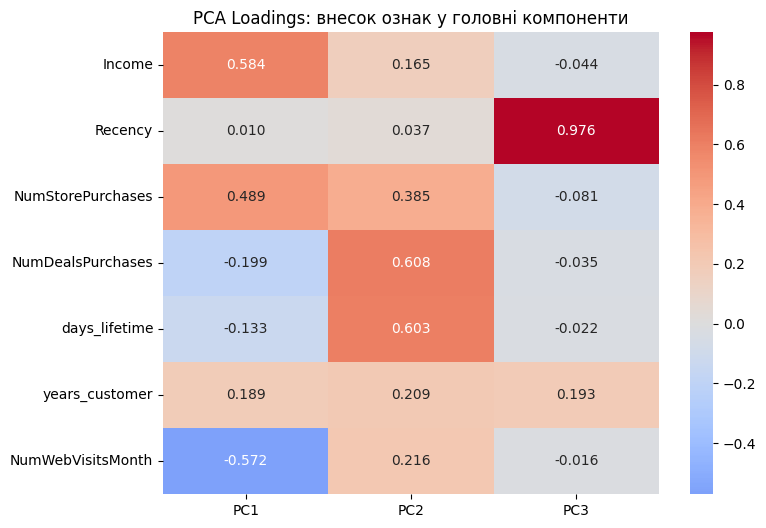

In [17]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('PCA Loadings: внесок ознак у головні компоненти')
plt.show()

In [18]:
# Топ-3 ознаки для кожної компоненти
for pc in ['PC1', 'PC2', 'PC3']:
    sorted_loadings = loadings[pc].abs().sort_values(ascending=False)
    top = sorted_loadings.index[0]
    print(f"{pc}: найбільший вплив — '{top}' (loading = {loadings.loc[top, pc]:.4f})")
    print(f"Топ-3: {', '.join(sorted_loadings.index[:3])}\n")

PC1: найбільший вплив — 'Income' (loading = 0.5842)
Топ-3: Income, NumWebVisitsMonth, NumStorePurchases

PC2: найбільший вплив — 'NumDealsPurchases' (loading = 0.6081)
Топ-3: NumDealsPurchases, days_lifetime, NumStorePurchases

PC3: найбільший вплив — 'Recency' (loading = 0.9758)
Топ-3: Recency, years_customer, NumStorePurchases



У ході аналізу loadings було визначено, які саме вихідні ознаки формують кожну з головних компонент:

- Перша компонента (PC1) найбільше пов’язана з доходом клієнта (Income) та кількістю покупок у магазині, при цьому має негативний зв’язок із кількістю відвідувань сайту. Це дозволяє інтерпретувати PC1 як показник платоспроможності та ефективності конверсії клієнта (покупки vs перегляди).

- Друга компонента (PC2) визначається кількістю покупок зі знижками (NumDealsPurchases) та тривалістю взаємодії з клієнтом (days_lifetime), що вказує на рівень залученості та чутливість до маркетингових акцій.

- Третя компонента (PC3) майже повністю визначається змінною Recency, що означає, що вона відображає окремий аспект поведінки клієнта — давність останньої покупки, і є слабо пов’язаною з іншими ознаками.

Таким чином, PCA дозволив виділити три основні незалежні фактори в даних: платоспроможність клієнта, залученість до акцій та актуальність взаємодії з компанією.

### Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [19]:
# Видаляємо Income
features_no_income = [f for f in features if f != 'Income']
X_no_income = X[features_no_income]

# Стандартизація та PCA
scaler_ni = StandardScaler()
X_ni_scaled = scaler_ni.fit_transform(X_no_income)

pca_ni = PCA(n_components=3, random_state=42)
pca_ni.fit(X_ni_scaled)

,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [20]:
# Нові loadings без Income
loadings_ni = pd.DataFrame(
    pca_ni.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features_no_income
)

loadings_ni.round(4)

,PC1,PC2,PC3
Recency,-0.0144,0.0749,0.9902
NumStorePurchases,-0.3812,0.6292,-0.1111
NumDealsPurchases,0.4456,0.4615,-0.0618
days_lifetime,0.3838,0.4679,0.0068
years_customer,-0.1773,0.3936,0.0563
NumWebVisitsMonth,0.6908,-0.1079,0.0099


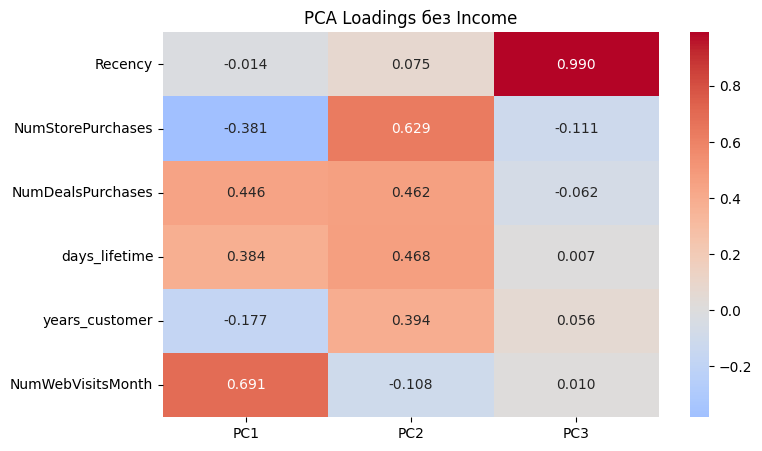

In [21]:
plt.figure(figsize=(8, 5))
sns.heatmap(loadings_ni, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('PCA Loadings без Income')
plt.show()

In [22]:
# Топ ознаки
for pc in ['PC1', 'PC2', 'PC3']:
    sorted_l = loadings_ni[pc].abs().sort_values(ascending=False)
    top = sorted_l.index[0]
    print(f"{pc}: найбільший вплив — '{top}' (loading = {loadings_ni.loc[top, pc]:.4f})")
    print(f"Топ-3: {', '.join(sorted_l.index[:3])}\n")

PC1: найбільший вплив — 'NumWebVisitsMonth' (loading = 0.6908)
Топ-3: NumWebVisitsMonth, NumDealsPurchases, days_lifetime

PC2: найбільший вплив — 'NumStorePurchases' (loading = 0.6292)
Топ-3: NumStorePurchases, days_lifetime, NumDealsPurchases

PC3: найбільший вплив — 'Recency' (loading = 0.9902)
Топ-3: Recency, NumStorePurchases, NumDealsPurchases



In [23]:
# Пояснена дисперсія: порівняння
print("Пояснена дисперсія (без Income):")
for i, ratio in enumerate(pca_ni.explained_variance_ratio_, 1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

cum_ni = np.cumsum(pca_ni.explained_variance_ratio_)
cum_orig = np.cumsum(pca.explained_variance_ratio_)

print(f"\nКумулятивна (3 компоненти):")
print(f"З Income:    {cum_orig[-1]*100:.2f}%")
print(f"Без Income:  {cum_ni[-1]*100:.2f}%")

Пояснена дисперсія (без Income):
PC1: 0.2739 (27.39%)
PC2: 0.2144 (21.44%)
PC3: 0.1668 (16.68%)

Кумулятивна (3 компоненти):
З Income:    65.85%
Без Income:  65.52%


Після вилучення ознаки Income структура головних компонент змінилася лише частково. Перша компонента (PC1), яка раніше описувала рівень доходу та купівельної активності, почала відображати поведінкові характеристики клієнтів, зокрема кількість відвідувань сайту та взаємодію з акціями. Друга компонента (PC2), що характеризує активність покупок і залученість клієнта, залишилася майже незмінною, що свідчить про її стабільність. Третя компонента (PC3), як і раніше, визначається ознакою Recency і відображає окремий незалежний фактор — давність останньої взаємодії.

Водночас кумулятивна частка поясненої дисперсії для трьох компонент майже не змінилася (65.85% → 65.52%), що свідчить про те, що ознака Income не є критичною для опису структури даних і її вплив частково компенсується іншими змінними.

Таким чином, основні патерни в даних визначаються не лише доходом, а й поведінковими характеристиками клієнтів.

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [24]:
# t-SNE до 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

In [25]:
# DataFrame з координатами t-SNE + кластери + оригінальні ознаки для hover
df_tsne = pd.DataFrame(X_tsne, columns=['tSNE_1', 'tSNE_2'])
df_tsne['Cluster'] = clusters.astype(str)

for feat in features:
    df_tsne[feat] = X_selected[feat].values

df_tsne.head()

,tSNE_1,tSNE_2,Cluster,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,-5.884777,18.133171,2,58138,58,4,3,663,57,7
1,-1.367273,-32.100624,0,46344,38,2,2,113,60,5
2,30.136362,-1.045601,1,71613,26,10,1,312,49,4
3,-49.336620,-28.135735,0,26646,26,4,2,139,30,6
4,-10.036283,36.473961,2,58293,94,6,5,161,33,5


In [26]:
# Інтерактивний 2D-графік
fig = px.scatter(
    df_tsne,
    x='tSNE_1', y='tSNE_2',
    color='Cluster',
    hover_data=features,
    title='t-SNE: Кластеризація клієнтів (KMeans, K=3)',
    opacity=0.7
)
fig.show()

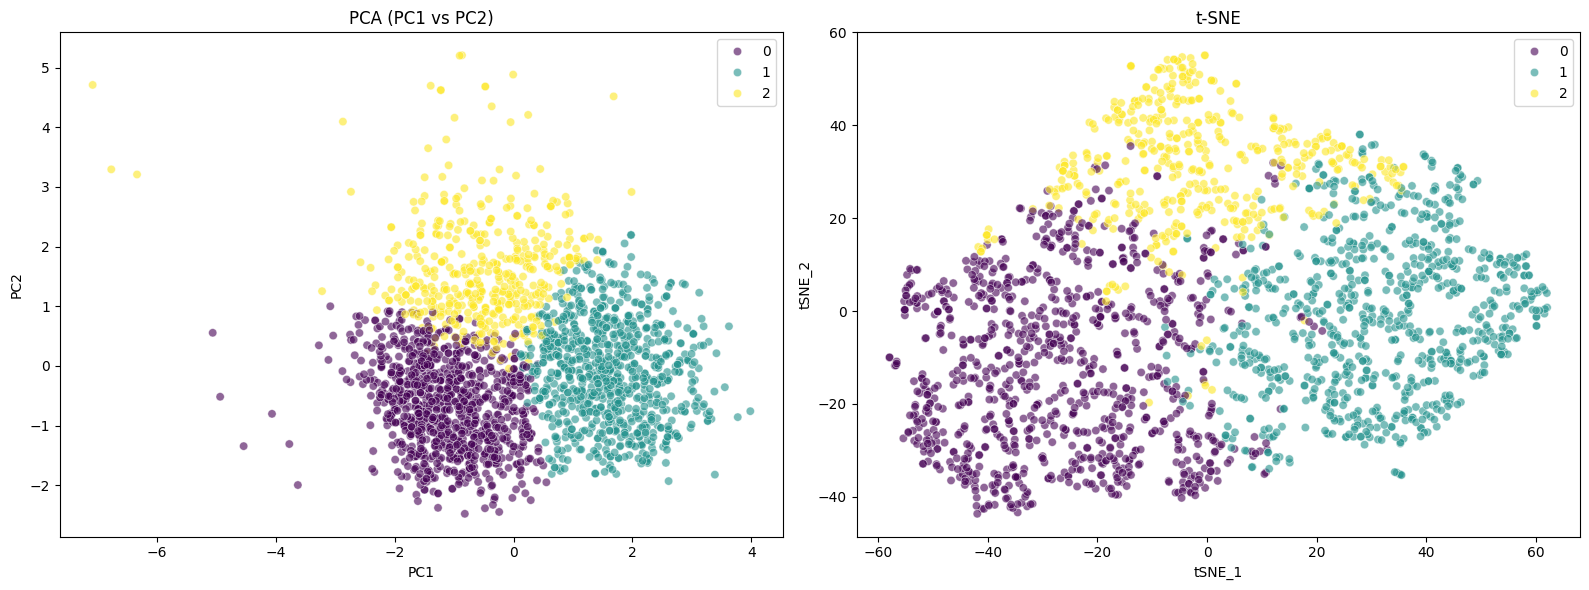

In [27]:
# Порівняння PCA vs t-SNE (статичні графіки)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', ax=axes[0], alpha=0.6)
axes[0].set_title('PCA (PC1 vs PC2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=clusters, palette='viridis', ax=axes[1], alpha=0.6)
axes[1].set_title('t-SNE')
axes[1].set_xlabel('tSNE_1')
axes[1].set_ylabel('tSNE_2')

plt.tight_layout()
plt.show()

In [28]:
# Середні значення ознак по кластерах
df_analysis = X_selected.copy()
df_analysis['Cluster'] = clusters

cluster_means = df_analysis.groupby('Cluster').mean().round(2)
cluster_means

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
Cluster,,,,,,,
0,33054.88,48.47,3.17,1.81,312.55,41.91,6.51
1,72551.55,49.35,8.34,1.44,315.25,47.35,3.07
2,51950.66,50.09,6.71,5.00,509.48,48.24,6.87


In [29]:
print("Розмір кластерів:")
print(df_analysis['Cluster'].value_counts().sort_index())

Розмір кластерів:
Cluster
0    961
1    823
2    455
Name: count, dtype: int64


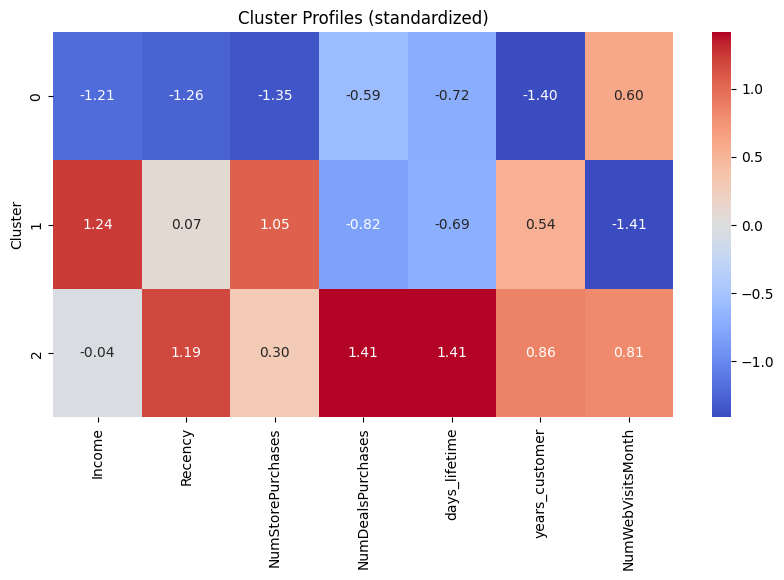

In [30]:
# Heatmap кластерних профілів (стандартизовані для порівняння)
scaler_profile = StandardScaler()
cluster_means_scaled = pd.DataFrame(
    scaler_profile.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_means_scaled, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Cluster Profiles (standardized)')
plt.show()

Використання методу t-SNE дозволило отримати більш чітку візуалізацію кластерної структури порівняно з PCA. На відміну від PCA, де спостерігається часткове перекриття кластерів, t-SNE формує більш виражені та відокремлені групи клієнтів, що свідчить про наявність локальних структур у даних.

Аналіз середніх значень ознак показав, що:

- Кластер 0 характеризується низьким доходом та низькою купівельною активністю і відповідає клієнтам з невисокою цінністю для бізнесу
- Кластер 1 об’єднує клієнтів з високим доходом та високою купівельною активністю, які при цьому майже не залежать від акцій і здійснюють покупки більш цілеспрямовано
- Кластер 2 включає активних і лояльних клієнтів із середнім доходом, які мають довгий життєвий цикл взаємодії з компанією, часто відвідують сайт і активно реагують на маркетингові акції

Таким чином, t-SNE дозволив краще візуалізувати сегментацію клієнтів, а додатковий аналіз ознак допоміг інтерпретувати бізнес-значення кожного кластера.

Водночас слід враховувати, що t-SNE зберігає локальні структури, але не гарантує коректного відображення глобальних відстаней між кластерами, тому його результати варто використовувати разом із іншими методами, такими як PCA.